In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
from google.colab import files
uploaded = files.upload()

Saving StudentsPerformance.csv to StudentsPerformance.csv


In [3]:
df = pd.read_csv('StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.shape

(1000, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [8]:

df['gender'] = df['gender'].replace({'female':0,'male':1})

In [9]:
df['gender'].value_counts()

,count
gender,
0,518
1,482


In [12]:
df['lunch'] = df['lunch'].replace({'standard':0,'free/reduced':1})
df['lunch'].value_counts()

,count
lunch,
0,645
1,355


In [13]:
df.drop('race/ethnicity', axis=1, inplace=True)

In [14]:
df.head()

,gender,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,bachelor's degree,0,none,72,72,74
1,0,some college,0,completed,69,90,88
2,0,master's degree,0,none,90,95,93
3,1,associate's degree,1,none,47,57,44
4,1,some college,0,none,76,78,75


In [18]:
df['parental level of education'].value_counts()
df['parental education']= df['parental level of education']

In [21]:
df['parental education'].value_counts()

,count
parental education,
some college,226
associate's degree,222
high school,196
some high school,179
bachelor's degree,118
master's degree,59


In [22]:
# some high school < high school < some college < associate's degree < bachelor < master

df['parental education']= df['parental education'].replace({'some high school':0, 'high school':1, 'some college':2, 'associate\'s degree':3, 'bachelor\'s degree':4, 'master\'s degree':5})

In [23]:
df['parental education'].value_counts()

,count
parental education,
2,226
3,222
1,196
0,179
4,118
5,59


In [24]:
df.head()

,gender,parental level of education,lunch,test preparation course,math score,reading score,writing score,parental education
0,0,bachelor's degree,0,none,72,72,74,4
1,0,some college,0,completed,69,90,88,2
2,0,master's degree,0,none,90,95,93,5
3,1,associate's degree,1,none,47,57,44,3
4,1,some college,0,none,76,78,75,2


In [25]:
df.drop('parental level of education', axis=1, inplace=True)

In [27]:
df['test preparation course'].value_counts()
df['test preparation']= df['test preparation course'].replace({'none':0, 'completed':1})

In [30]:
df.drop('test preparation course', axis=1, inplace=True)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   gender              1000 non-null   int64
 1   lunch               1000 non-null   int64
 2   math score          1000 non-null   int64
 3   reading score       1000 non-null   int64
 4   writing score       1000 non-null   int64
 5   parental education  1000 non-null   int64
 6   test preparation    1000 non-null   int64
dtypes: int64(7)
memory usage: 54.8 KB


In [32]:
df.head()

,gender,lunch,math score,reading score,writing score,parental education,test preparation
0,0,0,72,72,74,4,0
1,0,0,69,90,88,2,1
2,0,0,90,95,93,5,0
3,1,1,47,57,44,3,0
4,1,0,76,78,75,2,0


In [34]:
df.isnull().sum()


,0
gender,0
lunch,0
math score,0
reading score,0
writing score,0
parental education,0
test preparation,0


In [35]:
df.duplicated().sum()

np.int64(0)

In [36]:
df.to_csv('Students_perf')

In [41]:
from sklearn.preprocessing import StandardScaler


In [42]:
from sklearn.linear_model import LinearRegression

In [43]:
scaler= StandardScaler()
lr = LinearRegression()

In [44]:
X = df.drop('math score', axis=1)
y = df['math score']

In [45]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [46]:
X_train= scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)

In [47]:
lr.fit(X_train, y_train)


LinearRegression()

In [48]:
y_pred = lr.predict(X_test)

In [49]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [50]:
print('Mean Squared Error:', mse)
print('R-squared:', r2)

Mean Squared Error: 28.83183494308784
R-squared: 0.8815154741582593


Text(0, 0.5, 'Predicted Math Scores')

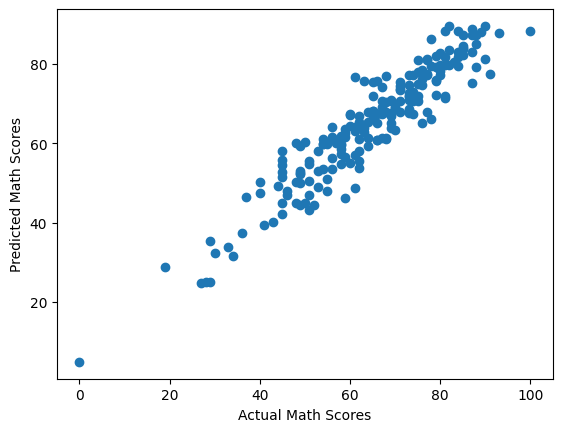

In [51]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Math Scores')
plt.ylabel('Predicted Math Scores')

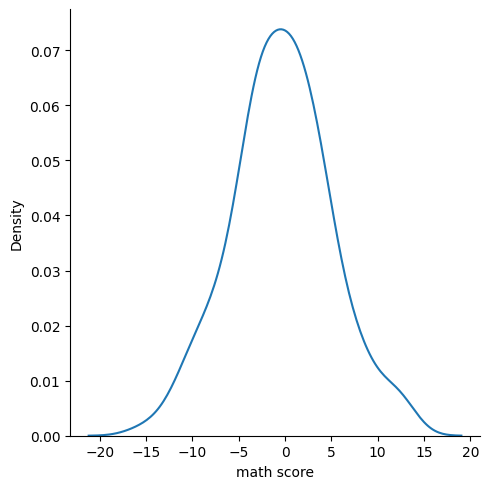

In [52]:
resid= y_test - y_pred
sns.displot(resid, kind='kde')

Text(0, 0.5, 'Residuals')

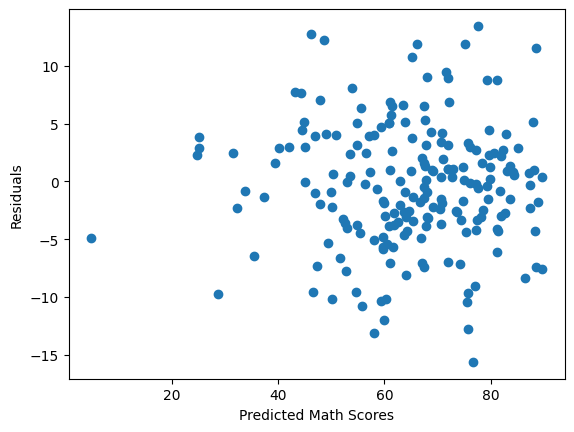

In [53]:
plt.scatter(y_pred, resid)
plt.xlabel('Predicted Math Scores')
plt.ylabel('Residuals')